# Your name here: 

# About

The purpose of this exercise is to simulate a live-coding test in a data science interview.

# Question 1 

$n!$ is read as "n factorial" and defined as:

$$
n! = n \times (n - 1) \times \cdots \times 2 \times 1
$$

Write a function called `factorial(n)` that implements $n!$ for any number. Return the factorial. And if the numbered entered is equal to 7, also print "KDB forever".



In [1]:
#write code here
def factorial(n: int) -> int:
    if n < 0:
        raise ValueError("n must be a non‑negative integer")
    if n == 7:
        print("KDB forever")
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


In [2]:
# test your function for factorial(n=3)
factorial(3)


6

In [139]:
# test your function for factorial(n=7)
factorial(7)

KDB forever


5040

# Question 2

Simulate 10,000 observations of the random variable $x_i \sim N(\mu = 0, \sigma^2 = 4)$.

Mean  : -0.0043
Std   : 2.0069
Min   : -7.8448
Max   : 7.8525


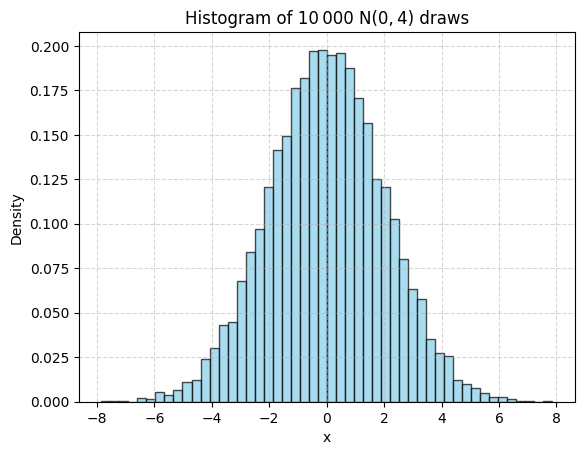

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

mu   = 0.0          
sigma = 2.0          

n_draws = 10_000
x = np.random.normal(loc=mu, scale=sigma, size=n_draws)

print(f"Mean  : {x.mean():.4f}")
print(f"Std   : {x.std(ddof=1):.4f}")   
print(f"Min   : {x.min():.4f}")
print(f"Max   : {x.max():.4f}")

plt.hist(x, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
plt.title('Histogram of 10 000 N(0, 4) draws')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



# Question 3

Define a function called `p(x)` that takes an array of values and implements

$$
p(x) = \frac{1}{1 + \text{exp}(-x)}
$$



In [60]:
# your code here:
import numpy as np

def p(x):
    x_arr = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x_arr))

In [136]:
# test your function on numpy array x that you generated in previous question

x = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
y = np.random.randn(10)   

print("Input array x:\n", x)
print("\nSigmoid p(x) values:\n", p(x))
print("Input array y:\n", y)
print("\nSigmoid p(x) values:\n", p(y))


Input array x:
 [-3. -1.  0.  1.  3.]

Sigmoid p(x) values:
 [0.04742587 0.26894142 0.5        0.73105858 0.95257413]
Input array y:
 [ 0.77969618 -0.0601545  -0.87278495 -0.92015223 -1.47716442 -0.51029116
  1.10269205  0.1778298  -0.52976771  0.80485594]

Sigmoid p(x) values:
 [0.68561463 0.48496591 0.29467514 0.28492688 0.1858561  0.37512527
 0.75076417 0.54434066 0.37057107 0.69101225]


# Question 4

Create an array `y` that implements the linear response based on `x` that you generated above:

$$
\begin{aligned}
y &= \beta_0 + \beta_1x +\epsilon\\
  &= 2 + 6x +\epsilon \\
\end{aligned}
$$

Where $\epsilon\sim N(0, 1)$

In [48]:

import numpy as np

x = np.asarray(x)          

np.random.seed(42)
epsilon = np.random.randn(x.size)  

y = 2 + 6 * x + epsilon

print("x[:5] =", x[:5])
print("y[:5] =", y[:5])

x[:5] = [ 0.99342831 -0.2765286   1.29537708  3.04605971 -0.46830675]
y[:5] = [ 8.45728399  0.20256408 10.419951   21.79938813 -1.04399387]


# Question 5

A mutual fund has \$50 000 to invest over three year horizon. There are three investment options.

1. **Annuity:** The fund can invest the same amount at the beginning of years 1, 2, and 3 and receive a 150\% return at the end of year 3 on the total capital invested.
2. **Bank account:** The fund can invest any amount at the beginning of each year and receive the capital plus a 6\% return at the end of the year. Additionally, the fund can borrow up to \$40,000 at the beginning of each year, with the borrowed amount plus interest (6\%) to be repaid at the end of the year.
3. **Venture capital:** Starting from year 3, the fund can invest up to \$50,000 in a high-risk venture capital project. This project has a 75\% chance of doubling the investment by the end of year 3. If the project fails (with a 25\% chance), the fund loses all the capital invested.

Obviously, the mutual fund wants to maximize total payout. 

### Question 5.1 reframe this as linear programming problem.

**Decision variables:**









**The objective functions:** 





**Constraints:** 






In [3]:
# your code here

import numpy as np
import pandas as pd

from scipy.optimize import linprog
import matplotlib.pyplot as plt


In [36]:
c_ex2 = np.array([1.50*3, 0, 0, 1.06, 1.50])

A_ex2 = np.array([[1,  1,  0,  0,  0],
                  [1, -1.06, 1, 0, 0],
                  [1, 0, -1.06, 1, -1]])

b_ex2 = np.array([50000, 0, 0])

bounds_ex2 = [(  0,    None),
              (-40000, None),
              (-40000, None),
              (-40000, None),
              (  0,   50000)]

res_ex2 = linprog(-c_ex2, A_eq=A_ex2, b_eq=b_ex2, bounds=bounds_ex2)

res_ex2

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -238356.9708737864
              x: [ 4.515e+04  4.854e+03 -4.000e+04 -3.755e+04  5.000e+04]
            nit: 0
          lower:  residual: [ 4.515e+04  4.485e+04  0.000e+00  2.454e+03
                              5.000e+04]
                 marginals: [ 0.000e+00  0.000e+00  5.463e-01  0.000e+00
                              0.000e+00]
          upper:  residual: [       inf        inf        inf        inf
                              0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                             -2.560e+00]
          eqlin:  residual: [ 0.000e+00  0.000e+00  0.000e+00]
                 marginals: [-1.770e+00 -1.670e+00 -1.060e+00]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0